**FASE 2: TRANSICIÓN A ARQUITECTURAS LIGERAS (MobileNetV2)**

Autor: Andoni Cabrera Fernández

Descripción: En este cuaderno se documenta el cambio hacia arquitecturas optimizadas para sistemas embebidos (TinyML). Se evalúa el rendimiento de la red MobileNetV2 sobre el rostro completo (enfoque holístico) para determinar si la eficiencia estructural de las convoluciones separables en profundidad mitiga el sobreajuste observado con VGG16.
Conclusión empírica: El modelo alcanza un techo técnico del ~40.7% en validación, confirmando que el "Sesgo de Identidad" es una limitación de los datos de entrada holísticos y no de la red.

**1. IMPORTACIÓN Y CONFIGURACIÓN**

In [1]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Descompresión rápida
ruta_zip = '/content/drive/MyDrive/TFG_Fatiga_Colab/Caras_Recortadas_Procesadas.zip'
ruta_trabajo = '/content/dataset_fatiga'
ruta_dataset = '/content/dataset_fatiga/Caras_Recortadas_Procesadas'

if not os.path.exists(ruta_trabajo):
    print("Descomprimiendo el dataset...")
    !unzip -q "{ruta_zip}" -d "{ruta_trabajo}"
    print("¡Descompresión completada!")
else:
    print("El dataset ya está listo en la memoria temporal.")

# 3. Creación de DataFrames
folds_dict = {f'Fold{i}': [] for i in range(1, 6)}
for carpeta in os.listdir(ruta_dataset):
    for i in range(1, 6):
        if f"Fold{i}" in carpeta:
            folds_dict[f'Fold{i}'].append(os.path.join(ruta_dataset, carpeta))

def crear_dataframe_desde_folds(lista_folds):
    rutas, etiquetas = [], []
    for ruta_fold in lista_folds:
        for raiz, _, archivos in os.walk(ruta_fold):
            clase = os.path.basename(raiz)
            if clase in ['Clase_0', 'Clase_5', 'Clase_10']:
                for archivo in archivos:
                    if archivo.endswith(('.jpg', '.png')):
                        rutas.append(os.path.join(raiz, archivo))
                        etiquetas.append(clase)
    return pd.DataFrame({'ruta': rutas, 'clase': etiquetas})

# PROTOCOLO 3-1-1: Entrenar con 2,3,4 | Validar con 5 | Testear con 1
df_train = crear_dataframe_desde_folds(folds_dict['Fold2'] + folds_dict['Fold3'] + folds_dict['Fold4'])
df_val = crear_dataframe_desde_folds(folds_dict['Fold5'])
df_test = crear_dataframe_desde_folds(folds_dict['Fold1'])

print(f"\nConfiguración finalizada.")
print(f"Train: {len(df_train)} | Val (Fold 5): {len(df_val)} | Test (Fold 1): {len(df_test)}")

Mounted at /content/drive
Descomprimiendo el dataset...
¡Descompresión completada!

Configuración finalizada.
Train: 60883 | Val (Fold 5): 20899 | Test (Fold 1): 20467


**2. GENERADORES Y DATA AUGMENTATION**

In [2]:
# Mantenemos el aumento de datos
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    df_val, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    df_test, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

Found 60883 validated image filenames belonging to 3 classes.
Found 20899 validated image filenames belonging to 3 classes.
Found 20467 validated image filenames belonging to 3 classes.


**3. CONSTRUCCIÓN DE LA ARQUITECTURA (MOBILENET-V2 OPTIMIZADA)**

In [3]:
# Cargamos MobileNetV2 congelada (Experimento de Control)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.1)), # Information Bottleneck
    BatchNormalization(),
    Dropout(0.7), # Dropout agresivo (70%)
    Dense(3, activation='softmax')
])

# Learning Rate de 1e-4 para MobileNetV2
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

print("\nArquitectura Final (Fase 2 - MobileNetV2):")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Arquitectura Final (Fase 2 - MobileNetV2):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,419 (8.93 MB)

 Trainable params: 82,307 (321.51 KB)

 Non-trainable params: 2,258,112 (8.61 MB)

**4. ENTRENAMIENTO Y DEMOSTRACIÓN DEL LÍMITE TÉCNICO**

In [4]:
ruta_keras = '/content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras'

callbacks_list = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ruta_keras, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("\nIniciando Entrenamiento MobileNetV2...")
historial = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks_list
)


Iniciando Entrenamiento MobileNetV2...
Epoch 1/50
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.4640 - loss: 9.2292
Epoch 1: val_accuracy improved from None to 0.28767, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 993s 510ms/step - accuracy: 0.5553 - loss: 6.1910 - val_accuracy: 0.2877 - val_loss: 3.3098 - learning_rate: 1.0000e-04
Epoch 2/50
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7227 - loss: 1.9195
Epoch 2: val_accuracy improved from 0.28767 to 0.29949, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 920s 483ms/step - accuracy: 0.7435 - loss: 1.5324 - val_accuracy: 0.2995 - val_loss: 2.

**5. VISUALIZACIÓN DEL LÍMITE ARQUITECTÓNICO**

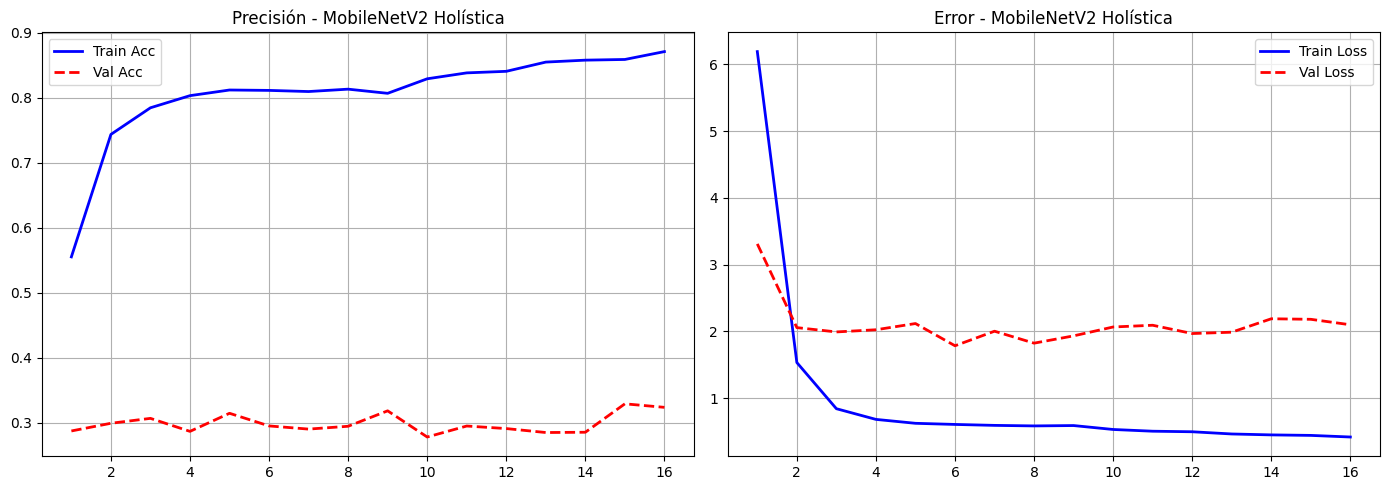

In [5]:
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Train Acc', linewidth=2)
plt.plot(epocas, val_acc, 'r--', label='Val Acc', linewidth=2)
plt.title('Precisión - MobileNetV2 Holística')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Train Loss', linewidth=2)
plt.plot(epocas, val_loss, 'r--', label='Val Loss', linewidth=2)
plt.title('Error - MobileNetV2 Holística')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

**6. MATRIZ DE CONFUSIÓN**


--- EVALUACIÓN FINAL SOBRE SUJETOS NO VISTOS (TEST CIEGO - FOLD 1) ---
640/640 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step


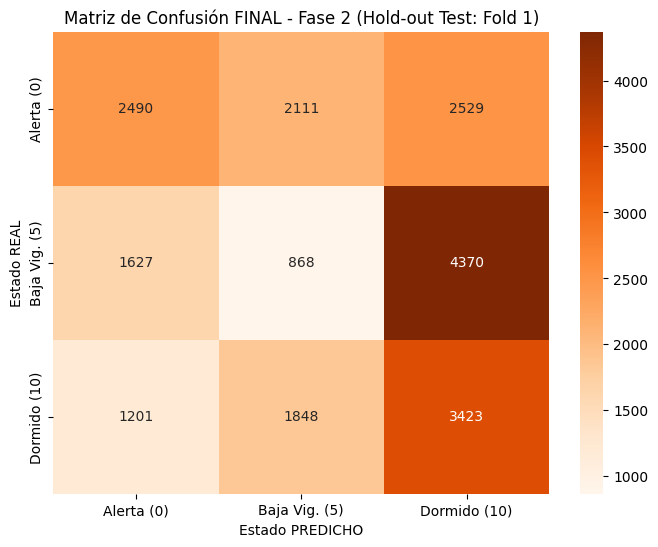


REPORTE DE CLASIFICACIÓN FINAL (FOLD 1):
               precision    recall  f1-score   support

   Alerta (0)       0.47      0.35      0.40      7130
Baja Vig. (5)       0.18      0.13      0.15      6865
 Dormido (10)       0.33      0.53      0.41      6472

     accuracy                           0.33     20467
    macro avg       0.33      0.33      0.32     20467
 weighted avg       0.33      0.33      0.32     20467



In [6]:
print("\n--- EVALUACIÓN FINAL SOBRE SUJETOS NO VISTOS (TEST CIEGO - FOLD 1) ---")

# Cargamos el mejor modelo guardado
ruta_modelo = '/content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase2_definitivo.keras'
model = tf.keras.models.load_model(ruta_modelo)

test_gen.reset()
predicciones = model.predict(test_gen)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_gen.classes

etiquetas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión FINAL - Fase 2 (Hold-out Test: Fold 1)')
plt.ylabel('Estado REAL')
plt.xlabel('Estado PREDICHO')
plt.show()

print("\nREPORTE DE CLASIFICACIÓN FINAL (FOLD 1):")
print(classification_report(y_true, y_pred, target_names=etiquetas))